In [71]:
import streamlit as st
# import mysql.connector
from langchain_community.utilities import SQLDatabase
from langchain_core.runnables import ensure_config, Runnable, RunnableConfig, RunnableLambda
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.pydantic_v1 import BaseModel, Field

from langgraph.graph import StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.graph import END, StateGraph, START
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.checkpoint.memory import MemorySaver

from typing import Annotated, Literal, Callable, Optional

from typing_extensions import TypedDict

from datetime import date, datetime

from dotenv import load_dotenv, find_dotenv

import os
import re

In [72]:
load_dotenv(find_dotenv())

True

In [73]:
# print(os.getenv('OPENAI_API_KEY'))

In [74]:
# Recommended
# _set_env("LANGCHAIN_API_KEY")
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "Primary Assistant with Discount Eligibility Checker & Price Whisperer"

In [75]:
def init_database(user: str, password: str, host: str, port: str, database: str) -> SQLDatabase:
  db_uri = f"mysql+mysqlconnector://{user}:{password}@{host}:{port}/{database}"
  return SQLDatabase.from_uri(db_uri)

In [76]:
db = init_database(
  user="root",
  password="root",
  host="localhost",
  port="3306",
  database="price_negotiation"
)
st.session_state.db = db

In [77]:
def handle_tool_error(state) -> dict:
    error = state.get("error")
    tool_calls = state["messages"][-1].tool_calls
    return {
        "messages": [
            ToolMessage(
                content=f"Error: {repr(error)}\n please fix your mistakes.",
                tool_call_id=tc["id"],
            )
            for tc in tool_calls
        ]
    }


def create_tool_node_with_fallback(tools: list) -> dict:
    return ToolNode(tools).with_fallbacks(
        [RunnableLambda(handle_tool_error)], exception_key="error"
    )


def _print_event(event: dict, _printed: set, max_length=1500):
    current_state = event.get("dialog_state")
    if current_state:
        print("Currently in: ", current_state[-1])
    message = event.get("messages")
    if message:
        if isinstance(message, list):
            message = message[-1]
        if message.id not in _printed:
            msg_repr = message.pretty_repr(html=True)
            if len(msg_repr) > max_length:
                msg_repr = msg_repr[:max_length] + " ... (truncated)"
            print(msg_repr)
            _printed.add(message.id)

def _print_event_streamlit(event: dict, _printed: set, max_length=1500):
    current_state = event.get("dialog_state")
    print(f"current_state first print {current_state}")
    if current_state:
        print(f"current_state second print after st.markdown {current_state}")
        print("Currently in: ", current_state[-1])
        print(f"current_state second print after st.markdown {current_state}")
    message = event.get("messages")
    print(f"message = event.get {message}")
    if message:
        if isinstance(message, list):
            message = message[-1]
            print(f"message from message[-1] {message}")
        if message.id not in _printed:
            msg_repr = message.pretty_repr(html=False)
            print(f"msg_repr {msg_repr}")
            # print(f"message.id {message.id}")
            # print(f"message.content {message.content}")
            # print(f"tool_calls_key {message.tool_calls}")
            if len(msg_repr) > max_length:
                msg_repr = msg_repr[:max_length] + " ... (truncated)"
            if 'Ai Message' in msg_repr:
                if (not message.tool_calls):
                    st.markdown(message.content)
                    st.session_state.chat_history.append(AIMessage(content=message.content))
            # if 'Ai Message' in msg_repr:
            #     test_text = pattern.sub('',msg_repr)
            #     print(f"test_text {test_text}")
            #     # print(len(test_text))
            #     st.markdown(test_text)
            _printed.add(message.id)




In [78]:
def update_dialog_stack(left: list[str], right: Optional[str]) -> list[str]:
    """Push or pop the state."""
    if right is None:
        return left
    if right == "pop":
        return left[:-1]
    return left + [right]

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    user_info: str
    dialog_state: Annotated[
        list[
            Literal[
                "assistant",
                "discount_eligibity_checker",
                "price_whisperer",
            ]
        ],
        update_dialog_stack,
    ]
    interaction_count: int
    discount_offer: list[float]
    counter_offer: list[float]

# This node will be shared for exiting all specialized assistants
def pop_dialog_state(state: State) -> dict:
    """Pop the dialog stack and return to the main assistant.

    This lets the full graph explicitly track the dialog flow and delegate control
    to specific sub-graphs.
    """
    messages = []
    if state["messages"][-1].tool_calls:
        # Note: Doesn't currently handle the edge case where the llm performs parallel tool calls
        messages.append(
            ToolMessage(
                content="Resuming dialog with the host assistant. Please reflect on the past conversation and assist the user as needed.",
                tool_call_id=state["messages"][-1].tool_calls[0]["id"],
            )
        )
    return {
        "dialog_state": "pop",
        "messages": messages,
    }


In [79]:
class Assistant:
    def __init__(self, runnable: Runnable):
        self.runnable = runnable

    def __call__(self, state: State, config: RunnableConfig):
        while True:
            result = self.runnable.invoke(state)
            # If the LLM happens to return an empty response, we will re-prompt it
            # for an actual response.
            if not result.tool_calls and (
                not result.content
                or isinstance(result.content, list)
                and not result.content[0].get("text")
            ):
                messages = state["messages"] + [("user", "Respond with a real output.")]
                state = {**state, "messages": messages}
                messages = state["messages"] + [("user", "Respond with a real output.")]
                state = {**state, "messages": messages}
            else:
                break
        return {"messages": result}

In [80]:
class CompleteOrEscalate(BaseModel):
    """A tool to mark the current task as completed and/or to escalate control of the dialog to the main assistant,
    who can re-route the dialog based on the user's needs."""

    cancel: bool = True
    reason: str

    class Config:
        schema_extra = {
            "example": {
                "cancel": True,
                "reason": "User changed their mind about the current task.",
            },
            "example 2": {
                "cancel": True,
                "reason": "I have fully completed the task.",
            },
            "example 3": {
                "cancel": False,
                "reason": "I need to search the user's purchase history for more information.",
            },
        }

In [81]:
def create_entry_node(assistant_name: str, new_dialog_state: str) -> Callable:
    def entry_node(state: State) -> dict:
        tool_call_id = state["messages"][-1].tool_calls[0]["id"]
        return {
            "messages": [
                ToolMessage(
                    content=f"The assistant is now the {assistant_name}. Reflect on the above conversation between the host assistant and the user."
                    f" The user's intent is unsatisfied. Use the provided tools to assist the user. Remember, you are {assistant_name},"
                    " and the eligibity check, negotiation, recommendation, other other action is not complete until after you have successfully invoked the appropriate tool."
                    " If the user changes their mind or needs help for other tasks, call the CompleteOrEscalate function to let the primary host assistant take control."
                    " Do not mention who you are - just act as the proxy for the assistant.",
                    tool_call_id=tool_call_id,
                )
            ],
            "dialog_state": new_dialog_state,
        }

    return entry_node

In [82]:
query_fetch_customer_info = """
    SELECT 
        c.customer_id,
        c.first_name,
        c.last_name,
        c.customer_email,
        c.customer_location,
        c.num_products_bought,
        ci.interaction_type,
        ci.interaction_date,
        ci.quantity,
        p.product_id,
        p.product_name,
        p.product_price,
        p.reduced_product_price,
        p.product_description,
        p.product_image,
        p.units_available,
        b.brand_name,
        ca.category_name,
        v.vendor_name,
        v.vendor_location,
        v.num_listings
    FROM 
        Customer c
    LEFT JOIN 
        CustomerInteractions ci ON c.customer_id = ci.customer_id
    LEFT JOIN 
        Product p ON ci.product_id = p.product_id
    LEFT JOIN 
        Brand b ON p.brand_id = b.brand_id
    LEFT JOIN 
        Category ca ON p.category_id = ca.category_id
    LEFT JOIN 
        Vendors v ON p.vendor_id = v.vendor_id
    WHERE
        c.customer_id = :customer_id
    ORDER BY 
        ci.interaction_date;
"""

In [83]:
def fetch_customer_information() -> list[dict]:
    """Fetch all purchases for the customer along with corresponding purchased product details, 
    i.e., product brand, product category, purchase data, quantities of purchased items.

    Fetch all information of the products in the cart as well as in the wishlist for the customer.

    Returns:
        A list of dictionaries where each dictionary contains the purchase details,
        associated product details, and the purchase dates for each purchase belonging to the customer.
    """
    config = ensure_config()  # Fetch from the context
    configuration = config.get("configurable", {})
    customer_id = configuration.get("customer_id", None)
    # customer_id = 17
    if not customer_id:
        raise ValueError("No passenger ID configured.")

    sql_command = query_fetch_customer_info
    sql_parameters = {'customer_id': customer_id}
                    
    retreived_result_obj = db.run(command=sql_command,
                                  fetch='cursor',
                                  parameters=sql_parameters 
                                 )
    logged_in_customer_row_mapping_info = retreived_result_obj.mappings().all()
    # print(logged_in_customer_row_mapping_info)
    
    # Converting RowMapping to dictionary
    logged_in_customer_info = [dict(row) for row in logged_in_customer_row_mapping_info]

    return logged_in_customer_info

In [84]:
loyalty_customer_eligibity = [{"loyalty_customer_num_purchase_days": 3},
                              {"loyalty_customer_bulk_purchases_quantity": 30},
                            ]

In [85]:
# llm = ChatOpenAI(temperature=0, 
#                  model="gpt-3.5-turbo")
llm = ChatOpenAI(temperature=0,
                 model='gpt-4o-mini')

In [86]:
@tool
def loyalty_customer_check() -> str:
    """Check if the customer meets the loyalty customer conditions"""
    config = ensure_config()
    configuration = config.get("configurable", {})
    customer_id = configuration.get("customer_id", None)
    print(f"customer_id is {customer_id}")
    # customer_id = 17
    if not customer_id:
        raise ValueError("No customer ID configured.")
    
    query_loyalty_customer_check = """
        SELECT customer_id, COUNT(DISTINCT DATE(interaction_date)) AS purchase_days
                    FROM CustomerInteractions
                    WHERE interaction_type = 'purchase' AND customer_id = :customer_id
                    GROUP BY customer_id
                    HAVING purchase_days >= :loyalty_customer_num_purchase_days;
    """
    sql_command = query_loyalty_customer_check
    sql_parameters = {'customer_id': customer_id, 
                      'loyalty_customer_num_purchase_days': loyalty_customer_eligibity[0].get('loyalty_customer_num_purchase_days')}
                    
    loyalty_customer_eligibity_info = db.run(command=sql_command,
                                  fetch='one',
                                  parameters=sql_parameters 
                                 )

    if not loyalty_customer_eligibity_info:
        return "The logged in customer does not meet requirements for being a loyalty customer."   

    return "The logged in customer meets requirements for being a loyalty customer and is eligible for discount offers."

In [87]:
@tool
def bulk_purchases_check() -> list[dict]:
    """Check if the customer has purchases items in bulk"""
    config = ensure_config()
    configuration = config.get("configurable", {})
    customer_id = configuration.get("customer_id", None)
    # return (customer_id)
    # customer_id = 17
    if not customer_id:
        raise ValueError("No customer ID configured.")
    
    query_bulk_purchases_check = """
        SELECT DISTINCT ci.customer_id, ci.product_id
            FROM (
                    -- Condition 1: Single purchase of 30 or more units on a particular day within the last 3 months
                    SELECT customer_id, product_id
                    FROM CustomerInteractions
                    WHERE interaction_type = 'purchase' 
                    AND quantity >= :loyalty_customer_bulk_purchases_quantity 
                    AND interaction_date >= DATE_SUB(CURDATE(), INTERVAL 3 MONTH)
                    AND customer_id = :customer_id
                    UNION
                    
                    -- Condition 2: Multiple purchases summing up to 30 or more units within the last 3 months
                    SELECT customer_id, product_id
                    FROM CustomerInteractions
                    WHERE interaction_type = 'purchase'
                    AND interaction_date >= DATE_SUB(CURDATE(), INTERVAL 3 MONTH)
                    AND customer_id = :customer_id
                    GROUP BY customer_id, product_id
                    HAVING SUM(quantity) >= :loyalty_customer_bulk_purchases_quantity
                    UNION
                    
                    -- Condition 3: 30 or more units in the cart for today's purchase
                    SELECT customer_id, product_id
                    FROM CustomerInteractions
                    WHERE interaction_type = 'cart_add' 
                    AND quantity >= :loyalty_customer_bulk_purchases_quantity 
                    AND DATE(interaction_date) = CURDATE()
                    AND customer_id = :customer_id
            ) AS ci
    """
    
    sql_command = query_bulk_purchases_check
    sql_parameters = {'customer_id': customer_id, 
                      'loyalty_customer_bulk_purchases_quantity': loyalty_customer_eligibity[1].get('loyalty_customer_bulk_purchases_quantity')}
                    
    retreived_result_obj = db.run(command=sql_command,
                                            fetch='cursor',
                                            parameters=sql_parameters 
                                            )
    # print(retreived_result_obj)
    bulk_purchases_retreived_info = retreived_result_obj.mappings().all()

    # Converting RowMapping to dictionary
    bulk_purchases_assessment_info = [dict(row) for row in bulk_purchases_retreived_info]
    print(bulk_purchases_assessment_info)

    return bulk_purchases_assessment_info


In [88]:
# Discount eligibility checking assistant
discount_eligibility_check_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a specialized assistant for checking eligibity of customers for discounts. "
            " The primary assistant delegates work to you whenever a new user/ customer logs in the system. "
            " You interact with customers to offer them special discounts. "
            " These discounts are subject to if the customer qualifies as a loyalty customer. " 
            
            "First of all check if the user is a valid logged in user. " 
            " To verify this, evaluate {user_info}. " 
            "To be a loyalty customer there should be a purchase record associated with the customer for a minumun of 10 unique dates. If there are more than one purchase on a day, count that day only once. "
            ' If the customer is not a loyalty customer, "CompleteOrEscalate" the dialog to the host assistant. "'
            " Otherwise, proceed forward with the evaluation of bulk purchases associated with the customer. "
            
            "The customer is eligible to get a discount on a particular product if the customer has purchased 30 or more units of the same product in one purchase on a day. "
            " The customer is eligible for a discount if the customer has purchased 30 or more units of the same product in multiple purchases. "
            " The customer is also eligible for a discount if the customer has put 30 or more units of the same product in the cart for today's purchase. "

            "To be eligible for the discount, the customer needs to meet both the loyalty customer requirements and the bulk purchases requirement. "
            "If the customer meets requirements for being a loyalty customer but does not meet the requirements of bulk puchases, then the customer is not eligible for the discount. "
            ' "CompleteOrEscalate" the dialog to the host assistant. '

            "Remember that you are only checking the eligibility of the customer for discount. Offering discounts is not your responsibility. "
            " You should just inform customers of their eligibility status. "

            "\n\nCurrent customer information:\n<User>\n{user_info}\n</User>"
            "\n\nIf none of your tools are appropriate for evaluating the eligibity of customers for discounts, then"
            ' "CompleteOrEscalate" the dialog to the host assistant. Do not waste the user\'s time. Do not make up invalid tools or functions.'
            "\n\nSome examples for which you should CompleteOrEscalate:\n"
            " - 'On which products can I have the discount?'\n"
            " - 'What is the general discount policy?'\n"
            " - 'What is the refund policy'\n"
            " - 'Discount eligibility checking completed'",
        ),
        ("placeholder", "{messages}"),
    ]
)

discount_eligibility_check_tools = [loyalty_customer_check, bulk_purchases_check]
customer_discount_eligibility_runnable = discount_eligibility_check_prompt | llm.bind_tools(
    discount_eligibility_check_tools + [CompleteOrEscalate]
)

In [89]:
@tool
def fetch_common_products_cart_history() -> list[dict]:
    """Fetch products that are present in the cart today, which have been purchased in bulk in the past"""
    config = ensure_config()
    configuration = config.get("configurable", {})
    customer_id = configuration.get("customer_id", None)
    # customer_id = 17
    if not customer_id:
        raise ValueError("No customer ID configured.")
       
    query_common_products_cart_history = """
        SELECT DISTINCT today_cart.customer_id, today_cart.product_id
            FROM (
                -- Condition 1: Bulk purchases in the last 3 months
                SELECT customer_id, product_id
                FROM CustomerInteractions
                WHERE interaction_type = 'purchase'
                AND interaction_date >= DATE_SUB(CURDATE(), INTERVAL 3 MONTH)
                GROUP BY customer_id, product_id
                HAVING SUM(quantity) >= :loyalty_customer_bulk_purchases_quantity
                
                UNION
                
                -- Condition 2: Single purchases of 30 or more units on a particular day within the last 3 months
                SELECT customer_id, product_id
                FROM CustomerInteractions
                WHERE interaction_type = 'purchase'
                AND quantity >= :loyalty_customer_bulk_purchases_quantity
                AND interaction_date >= DATE_SUB(CURDATE(), INTERVAL 3 MONTH)

                UNION
                
                -- Condition 3: 30 or more units in the cart for today's purchase
                SELECT customer_id, product_id
                FROM price_negotiation.customerinteractions
                WHERE interaction_type = 'cart_add'
                AND quantity >= :loyalty_customer_bulk_purchases_quantity
                AND DATE(interaction_date) = CURDATE()
            ) AS bulk_purchases
            INNER JOIN (
                -- Today's cart items
                SELECT customer_id, product_id
                FROM CustomerInteractions
                WHERE interaction_type = 'cart_add'
                AND DATE(interaction_date) = CURDATE()
            ) AS today_cart
            ON bulk_purchases.customer_id = today_cart.customer_id
            AND bulk_purchases.product_id = today_cart.product_id;
    """
    
    sql_command = query_common_products_cart_history
    sql_parameters = {'customer_id': customer_id, 
                      'loyalty_customer_bulk_purchases_quantity': loyalty_customer_eligibity[1].get('loyalty_customer_bulk_purchases_quantity')}
                    
    retreived_result_obj = db.run(command=sql_command,
                                  fetch='cursor',
                                  parameters=sql_parameters 
                                  )
    # print(retreived_result_obj)
    common_products_row_mapping_info = retreived_result_obj.mappings().all()

    # Converting Row Mapping to dictionary
    common_products_retreived_info = [dict(row) for row in common_products_row_mapping_info]
    print(common_products_retreived_info)

    return common_products_retreived_info

In [90]:
@tool
def fetch_price_info_for_price_negotiation() -> list[dict]:
    """ Fetch price related fields associated with the product eligbible for discount.
    """
    config = ensure_config()
    configuration = config.get("configurable", {})
    customer_id = configuration.get("customer_id", None)
    # customer_id = 17
    if not customer_id:
        raise ValueError("No customer ID configured.")
    
    query_price_info = """
        SELECT DISTINCT
            today_cart.customer_id,
            today_cart.product_id,
            p.product_name,
            p.product_price,
            p.reduced_product_price,
            p.product_margin_percent
        FROM (
            -- Condition 1: Bulk purchases in the last 3 months
            SELECT customer_id, product_id
            FROM CustomerInteractions
            WHERE interaction_type = 'purchase'
            AND interaction_date >= DATE_SUB(CURDATE(), INTERVAL 3 MONTH)
            GROUP BY customer_id, product_id
            HAVING SUM(quantity) >= :loyalty_customer_bulk_purchases_quantity
            
            UNION
            
            -- Condition 2: Single purchases of 30 or more units on a particular day within the last 3 months
            SELECT customer_id, product_id
            FROM CustomerInteractions
            WHERE interaction_type = 'purchase'
            AND quantity >= :loyalty_customer_bulk_purchases_quantity
            AND interaction_date >= DATE_SUB(CURDATE(), INTERVAL 3 MONTH)

            UNION
            
            -- Condition 3: 30 or more units in the cart for today's purchase
            SELECT customer_id, product_id
            FROM price_negotiation.customerinteractions
            WHERE interaction_type = 'cart_add'
            AND quantity >= :loyalty_customer_bulk_purchases_quantity
            AND DATE(interaction_date) = CURDATE()
        ) AS bulk_purchases
        INNER JOIN (
            -- Today's cart items
            SELECT customer_id, product_id
            FROM CustomerInteractions
            WHERE interaction_type = 'cart_add'
            AND DATE(interaction_date) = CURDATE()
        ) AS today_cart
        ON bulk_purchases.customer_id = today_cart.customer_id
        AND bulk_purchases.product_id = today_cart.product_id
        JOIN Product p ON today_cart.product_id = p.product_id;

    """
    sql_command = query_price_info
    sql_parameters = {'loyalty_customer_bulk_purchases_quantity': loyalty_customer_eligibity[1].get('loyalty_customer_bulk_purchases_quantity')}
    
    retreived_result_obj = db.run(command=sql_command,
                                  fetch='cursor',
                                  parameters=sql_parameters 
                                )
    common_products_price_row_mapping_info = retreived_result_obj.mappings().all()
    # print(registered_products_row_mapping_info)
    
    # Converting RowMapping to dictionary
    common_products_price_info = [dict(row) for row in common_products_price_row_mapping_info]
    print(common_products_price_info)
    
    return common_products_price_info

In [91]:
# @tool(parse_docstring=True)
@tool
def product_specific_discount_checker(product_id: int,
                                      state: State) -> str:
    """ This is the entry point to answer a product specific query about discount. Check if the querried product (product_id)
        is present in the extracted common products list. If yes, then using the product price info let the customer know of the
                                                                                                                               
        maximum possible discount. Otherwise, inform the customer that the product is not eligible for discount.
    """
    config = ensure_config()
    configuration = config.get("configurable", {})
    customer_id = configuration.get("customer_id", None)
    # customer_id = 17
    if not customer_id:
        raise ValueError("No customer ID configured.")

    query_common_products_cart_history = """
        SELECT DISTINCT today_cart.customer_id, today_cart.product_id
            FROM (
                -- Condition 1: Bulk purchases in the last 3 months
                SELECT customer_id, product_id
                FROM CustomerInteractions
                WHERE interaction_type = 'purchase'
                AND interaction_date >= DATE_SUB(CURDATE(), INTERVAL 3 MONTH)
                GROUP BY customer_id, product_id
                HAVING SUM(quantity) >= :loyalty_customer_bulk_purchases_quantity
                
                UNION
                
                -- Condition 2: Single purchases of 30 or more units on a particular day within the last 3 months
                SELECT customer_id, product_id
                FROM CustomerInteractions
                WHERE interaction_type = 'purchase'
                AND quantity >= :loyalty_customer_bulk_purchases_quantity
                AND interaction_date >= DATE_SUB(CURDATE(), INTERVAL 3 MONTH)

                UNION
                
                -- Condition 3: 30 or more units in the cart for today's purchase
                SELECT customer_id, product_id
                FROM price_negotiation.CustomerInteractions
                WHERE interaction_type = 'cart_add'
                AND quantity >= :loyalty_customer_bulk_purchases_quantity
                AND DATE(interaction_date) = CURDATE()
            ) AS bulk_purchases
            INNER JOIN (
                -- Today's cart items
                SELECT customer_id, product_id
                FROM CustomerInteractions
                WHERE interaction_type = 'cart_add'
                AND DATE(interaction_date) = CURDATE()
            ) AS today_cart
            ON bulk_purchases.customer_id = today_cart.customer_id
            AND bulk_purchases.product_id = today_cart.product_id;
    """
    
    sql_command = query_common_products_cart_history
    sql_parameters = {'customer_id': customer_id, 
                      'loyalty_customer_bulk_purchases_quantity': loyalty_customer_eligibity[1].get('loyalty_customer_bulk_purchases_quantity')}
                    
    retreived_result_obj = db.run(command=sql_command,
                                  fetch='cursor',
                                  parameters=sql_parameters 
                                  )
    # print(retreived_result_obj)
    common_products_row_mapping_info = retreived_result_obj.mappings().all()

    # Converting Row Mapping to dictionary
    common_products = [dict(row) for row in common_products_row_mapping_info]
    # print(common_products)

    # Check if product_id_to_check is in common_products
    is_present = any(product['product_id'] == product_id for product in common_products)

    # Print result
    print(f"Product ID {product_id} is {'present' if is_present else 'not present'} in common_products.")

    if is_present:
        query_price_info = """
            SELECT DISTINCT
                ci.customer_id,
                ci.product_id,
                p.product_name,
                p.product_price,
                p.reduced_product_price,
                p.product_margin_percent
            FROM
                CustomerInteractions ci
            JOIN
                Product p ON ci.product_id = p.product_id
            WHERE
                ci.interaction_type = 'cart_add'
                AND DATE(ci.interaction_date) = CURDATE()
                AND ci.product_id = :product_id;
        """

        sql_command = query_price_info
        sql_parameters = {'product_id': product_id}
        
        products_price_info_obj = db.run(command=sql_command,
                                         fetch='cursor',
                                         parameters=sql_parameters 
                                        )
        product_price_row_mapping_info = products_price_info_obj.mappings().all()
        
        # Converting RowMapping to dictionary
        product_price_info = [dict(row) for row in product_price_row_mapping_info]
        print(product_price_info)

        extracted_product_price_margin = product_price_info[0].get('product_margin_percent')
        discount_offer_1 = extracted_product_price_margin - (extracted_product_price_margin * 0.15)
        
        state['discount_offer'].append(discount_offer_1)
        state['interaction_count'] = 1

        return f"The product can have upto {discount_offer_1} percent discount. Would you like to start bargaining?"
    else:
        return "The product is not eligible for the discount"
    

In [92]:
@tool
def interactive_price_negotiation(product_id: int,
                                  state: State,
                                  customer_counter_offer: Optional[float] = None,) -> str:
    """ Based on customer response about the product and counter offers, engage with the customer. Evaluate customer's counter offer and
        offer discounts 3 times at most.
    """

    if state['interaction_count'] == None:
        state['interaction_count'] = 0
    
    if customer_counter_offer != None:
        state['counter_offer'].append(customer_counter_offer)
        
    if state['interaction_count'] == 0:
        query_price_info = """
            SELECT DISTINCT
                ci.customer_id,
                ci.product_id,
                p.product_name,
                p.product_price,
                p.reduced_product_price,
                p.product_margin_percent
            FROM
                CustomerInteractions ci
            JOIN
                Product p ON ci.product_id = p.product_id
            WHERE
                ci.interaction_type = 'cart_add'
                AND DATE(ci.interaction_date) = CURDATE()
                AND ci.product_id = :product_id;
        """

        sql_command = query_price_info
        sql_parameters = {'product_id': product_id}
        
        products_price_info_obj = db.run(command=sql_command,
                                         fetch='cursor',
                                         parameters=sql_parameters 
                                        )
        product_price_row_mapping_info = products_price_info_obj.mappings().all()
        
        # Converting RowMapping to dictionary
        product_price_info = [dict(row) for row in product_price_row_mapping_info]
        print(product_price_info)

        extracted_product_price_margin = product_price_info[0].get('product_margin_percent')
        discount_offer_1 = extracted_product_price_margin - (extracted_product_price_margin * 0.15)
        state['discount_offer'].append(discount_offer_1)
        print(f"discount_offer_1 -> {discount_offer_1}")
        print(f"discount_offers {state['discount_offer']}")
             
        state['interaction_count'] = state['interaction_count'] + 1
        print(f"bargaining_count print #1: {state['interaction_count']}")
        return f"The product can have upto {discount_offer_1} percent discount. Would you like to start bargaining?"

    elif state['interaction_count'] == 1:
        state['interaction_count'] = state['interaction_count'] + 1
        print(f"bargaining_count print #3: {state['interaction_count']}")

        # customer_counter_offer = state.get('counter_offer')[-1]
        customer_counter_offer = state['counter_offer'][-1]
        print(f"customer_counter_offer -> {customer_counter_offer}")
        if state['discount_offer'][-1] < customer_counter_offer:
            discount_offer_2 = customer_counter_offer * 0.6
            state['discount_offer'].append(discount_offer_2)
            print(f"discount_offer_2 -> {discount_offer_2}")
            print(f"discount_offers {state['discount_offer']}")
            return f"The product can have upto {discount_offer_2} percent discount. Would you like to accept or reject or counter offer?"
        elif state['discount_offer'][-1] > customer_counter_offer:
            return f"Are you sure about your offer of {customer_counter_offer} percent discount? or would you like to counter offer?"
        elif customer_counter_offer == state['discount_offer'][0]:
            return f"{customer_counter_offer} percent discount is the maximum you can get? Please provide another counter offer"
        
        state['interaction_count'] = state['interaction_count'] + 1
        print(f"bargaining_count print #2: {state['interaction_count']}")

    elif state['interaction_count'] == 2:
        state['interaction_count'] = state['interaction_count'] + 1
        print(f"bargaining_count print #3: {state['interaction_count']}")

        # customer_counter_offer = state.get('counter_offer')[-1]
        customer_counter_offer = state['counter_offer'][-1]
        print(f"customer_counter_offer -> {customer_counter_offer}")
        if state['discount_offer'][-1] < customer_counter_offer:
            discount_offer_3 = customer_counter_offer * 0.75
            state['discount_offer'].append(discount_offer_3)
            print(f"discount_offer_3 -> {discount_offer_3}")
            print(f"discount_offers {state['discount_offer']}")           
            return f"The product can have upto {discount_offer_3} percent discount. Would you like to accept or reject or counter offer?"
        elif state['discount_offer'][-1] > customer_counter_offer:
            return f"Are you sure about your offer of {customer_counter_offer} percent discount? or would you like to counter offer?"
        elif customer_counter_offer == state['discount_offer'][0]:
            return f"{customer_counter_offer} percent discount is the maximum you can get? Please provide another counter offer"
        else:
            return f"Not a valid option"
        
    elif state['interaction_count'] == 3:
        state['interaction_count'] = state['interaction_count'] + 1
        print(f"bargaining_count print #3: {state['interaction_count']}")

        # customer_counter_offer = state.get('counter_offer')[-1]
        customer_counter_offer = state['counter_offer'][-1]
        print(f"customer_counter_offer -> {customer_counter_offer}")
        print(f"counter_offer {state['counter_offer']}")
        if state['discount_offer'][-1] < customer_counter_offer:
            discount_offer_4 = customer_counter_offer * 0.90
            state['discount_offer'].append(discount_offer_4)
            print(f"discount_offer_4 -> {discount_offer_4}")
            print(f"discount_offers {state['discount_offer']}")
            return f"The product can have upto {discount_offer_4} percent discount. Would you like to accept or reject or counter offer?"
        elif state['discount_offer'][-2] > customer_counter_offer:
            state['interaction_count'] = state['interaction_count'] + 1
        elif customer_counter_offer == state['discount_offer'][0]:
            return f"{customer_counter_offer} percent discount is the maximum you can get? Please provide another counter offer"
        else:
            return f"Not a valid option"
        
    elif state['interaction_count'] == 4:
        state['interaction_count'] = state['interaction_count'] + 1
        print(f"maximum bargain limit is reached")

        # customer_counter_offer = state.get('counter_offer')[-1]
        customer_counter_offer = state['counter_offer'][-1]
        print(f"customer_counter_offer -> {customer_counter_offer}")
        print(f"counter_offer {state['counter_offer']}")
        if state['discount_offer'][-1] < customer_counter_offer:
            print("maximum bargain limit is reached")
            return f"The product can have final discount of {state['discount_offer'][-1]} percent. Would you like to accept or reject?"
        else:
            return f"The product can have final discount of {product_price_info[0].get('product_margin_percent')} percent. Would you like to start bargaining?"
                  
    else:
        state['interaction_count'] = state['interaction_count']
        print(f"bargaining_count print #5: {state['interaction_count']}")
        return f"You have reached the maximum limit on the discount that can be offered on the product."


In [93]:
import re
@tool
def extract_numbers_from_messages(state: State,
                                  customer_counter_offer: Optional[int] = None,) -> str:
    """ Extract numbers from messages and store them in relevant states. During the price negotiation process, 
        numbers mentioned in AIMessages are discount offers, whereas numbers mentioned in HumanMessages are counter offers.
        Discount offers should be stored in state['discount_offer'].
        Couner offers should be stored in state['counter_offer']

        Examples:
        AIMessage(content='The maximum possible discount on the saucepan is 13.55%'). Here 13.55% is the discount offer. state['discount_offer'] = 19.55
        HumanMessage(content='Counter offer on the saucepan is 23%'). Here 23% is the counter offer. state['counter_offer'] = 25
    """
    regx_pattern = r'\d+\.\d+|\d+'
    last_message = state["messages"][-1]

    if last_message['type'] == 'ai':
        matches = re.findall(regx_pattern, last_message['content'])    
        state['counter_offer'].append(matches[0])
    elif last_message['type'] == 'human':
        matches = re.findall(regx_pattern, last_message['content'])    
        state['discount_offer'].append(matches[0])
    else:
        print('The message is ToolMessage')
    
    return 'State graph successfully updated'


In [94]:
# Price negotiating assistant
price_negotiator_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a specialized assistant for offering product specific discounts to customers and negotiating price with them. "
            "Do not give out information to customers about product margin percentages associated with products. "
            "Do not give out information to customers about reduced prices associated with products. "

            " The primary assistant delegates work to you when the user asks about discounts on a specific product or specific products. "
            "Example: What is the discount on the saucepan?"
            "Example: Is there a deal on the cutting board?"
            "Example: Can I have an offer on the toaster?"

            "The primary assistant also delegates work to you when the user wants to start a price negotiating process. "
            "Example: Yes, please I want to negotiate price of the saucepan"
            "Example: Please connect, I want to know about offers or discount offers on the cutting board."

            "You interact with customers to offer them special discounts. "

            " When the primary assistant delegates you the task, it means that the logged in customer is a loyalty customer. "
            " When the primary assistant delegates you the task, it also means that the logged in customer has made bulk purchases in the past. "

            "Remember that bulk purchase means if a particular product has been purchased in quantities of 30 or more units in one purchase on a day. "
            " Also bulk purchase means that a product has been multiple times to make the accummulated quantity as 30 or more units. "
            " In addition, if there are 30 or more units of a particular product in the cart for today's purchase that counts as bulk purchase. "

            "For the products that meet bulk purchase criteria, fetch their pricing information. "
            "Do not disclose product margin percentages and reduced prices associated with products to customers. This information is for internal use only."
            "You are now ready to interact with the customer for negotiating the price. "

            "Check if the querried product (product_id) is present in the extracted common products list (common_products_retreived_info). "
            " If yes, then let the customer know of the maximum possible discount for that product (product_id). Store this value in discount_offer[0].  "
            " Otherwise, inform the customer that the product is not eligible for discount."
            "Request a response from the customer in the form of Accept, Reject, or Counter Offer. "
            ' If the customer\'s response is Accept, then "CompleteOrEscalate" the dialog to the host assistant.'
            ' If the customer\'s response is Reject, then "CompleteOrEscalate" the dialog to the host assistant.'
            " In the customer's response is Counter Offer, then evaluate the offer to make further decisions. "
            " Do not hand over the dialog to the host assistant if the customer is putting counter offers. "

            " Extract the number you have provided the customer as discount from your response and store it for future use. "
            "You can ask the customer to make a counter offer a maximum of 3 times. "
            "Keep track of how many times the customer makes a counter offer. Store this count in interaction_count. "

            "If the customer makes the first counter offer, you will not accept this offer instantly but you will evaluate it and respond accordingly based on a fixed criteria. "
            " Extract the value of the customer counter offer from customer's message and store it for future use. "

            " Atfer extracting the counter offer (counter_offer[0]) value, evaluate to check if it is greater than or smaller to the inital discount offer (discount_offer[0])"
                                                                                                                                                                                  
            ' If customer offer is greater than the offered discount, then go to "interactive_price_negotiation" for calculating the second discount offer, i.e., discount_offer[1]. '
                                                                                                                                                                 
            ' Use the saved and stored information about discount and counter offer in "interactive_price_negotiation" to come up with a new discount offer. '

            "If the customer makes the second counter offer, you will not accept this offer instantly but you will evaluate it and respond accordingly based on a fixed criteria. "
            ' Extract the value of the customer counter offer from customer\'s message and store it for future use. '
            " Atfer extracting the counter offer (counter_offer[1]) value, evaluate to check if it is greater than or smaller to the second discount offer (discount_offer[1])"
            ' If the customer\'s offer lies between the initial and second discount, then go to "interactive_price_negotiation" for calculating the third discount offer, i.e., discount_offer[2]. '
            ' Use the saved and stored information about discount and counter offer in "interactive_price_negotiation" to come up with a new discount offer. '

            "If the customer makes the third and final counter offer, you will not accept this offer instantly but you will evaluate it and respond accordingly based on a fixed criteria. "
            " Extract the value of the customer counter offer from customer's message and store it for future use. "
            " Atfer extracting the counter offer (counter_offer[2]) value, is greater than or smaller to the second discount offer (discount_offer[2])"
            ' If the customer\'s offer is less than the maximum possible discount, then go to "interactive_price_negotiation" for calculating the final discount offer, i.e., discount_offer[3]. '
            ' Use the saved and stored information about discount and counter offer in "interactive_price_negotiation" to come up with a new discount offer. '

            ' Any time in this negotiationg process if the customer\'s response is Accept, then "CompleteOrEscalate" the dialog to the host assistant.'
            ' Any time in this negotiationg process if the customer\'s response is Reject, then "CompleteOrEscalate" the dialog to the host assistant.'

            "As a specialized price negotiating assistant, you have permission to apply the negotiated discount to the bulk purchased products in the cart. "
            " You should not reduce the price of those items in the cart, which have been separated out as not meeting bulk purchases criteria."

            "Remember that you are here only for negotiating the price and offer discounts on selected products. Recommending other products and responding on general queries is not your responsibility. "

            "\n\nCurrent customer information:\n<User>\n{user_info}\n</User>"
            "\n\nIf none of your tools are appropriate for calculating discounts for customers and engaging in a price negotiation, then"
            ' "CompleteOrEscalate" the dialog to the host assistant. Do not waste the user\'s time. Do not make up invalid tools or functions.',
        ),
        ("placeholder", "{messages}"),
    ]
)

price_negotiation_general_tools = [fetch_common_products_cart_history, fetch_price_info_for_price_negotiation, product_specific_discount_checker, extract_numbers_from_messages]
price_negotiation_interim_tools = []
price_negotiation_interaction_tools = [interactive_price_negotiation]
price_negotiation_tools = price_negotiation_general_tools + price_negotiation_interaction_tools

pn_interactive_tool_names = {t.name for t in price_negotiation_interaction_tools}

price_negotiation_runnable = price_negotiator_prompt | llm.bind_tools(
    price_negotiation_tools
    + [CompleteOrEscalate]
)


In [95]:
product_catelogue_query = """
    SELECT 
        p.product_id,
        p.product_name,
        p.product_description,
        p.product_price,
        p.reduced_product_price,
        p.product_image,
        p.units_available,
        p.product_margin_percent,
        b.brand_name,
        c.category_name,
        v.vendor_name,
        v.vendor_location,
        v.num_listings AS vendor_num_listings,
        b.brand_name AS brand_name,
        c.category_name AS category_name
    FROM 
        Product p
    JOIN 
        Brand b ON p.brand_id = b.brand_id
    JOIN 
        Category c ON p.category_id = c.category_id
    JOIN 
        Vendors v ON p.vendor_id = v.vendor_id
    ORDER BY 
        p.product_name;

"""

In [96]:
@tool
def fetch_product_information() -> list[dict]:
    """Fetch all information about all products available in the database with corresponding 
    vendor, brand, & category info.

    Returns:
        A list of dictionaries of all products available in the database.
    """
    sql_command = product_catelogue_query
    # sql_parameters = {'customer_id': customer_id}
                    
    retreived_result_obj = db.run(command=sql_command,
                                  fetch='cursor',
                                #   parameters=sql_parameters 
                                 )
    registered_products_row_mapping_info = retreived_result_obj.mappings().all()
    print(registered_products_row_mapping_info)

    # Converting RowMapping to dictionary
    registered_products_info = [dict(row) for row in registered_products_row_mapping_info]
    
    return registered_products_info

In [97]:
# Primary Assistant
# The top-level assistant performs general Q&A and delegates specialized tasks to other assistants.
# The task delegation is a simple form of semantic routing / does simple intent detection

class ToDiscountEligibiltyCheckAssistant(BaseModel):
    """Transfers work to a specialized assistant to handle the evaluation of customers for discount offers."""

    # request: str = Field(
    #     description="Any necessary followup questions the discount eligibilty check assistant should clarify before proceeding.")
    information: str = Field(
        description="Inform the status and progress of the discount eligibilty check assistant."
    )

class ToPriceNegotiatingAssistant(BaseModel):
    """Transfers work to a specialized assistant to handle price negotiation and discount offers on specific products."""

    request: str = Field(
        description="Accept/ Reject/ Counter Offer response and counter offer from customers.")

    customer_counter_offer: float = Field(description="The offer or counter offer given by the customer.")
    
    class Config:
        schema_extra = {
            "example": {
                "customer_counter_offer": 0,
                "request": "Accept/ Reject/ Counter Offer response and counter offer from customers.",
            }
        }

# Prompt for the primary assistant
primary_assistant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful customer support assistant for Price Whisperer. "
            "Your primary role is to greet customers and search for company polices about discounts. "
            "You can also provide general information about the available products in the product catelogue. "
            "Do not give out information to customers about product margin percentages associated with products. "
            "Do not give out information to customers about reduced prices associated with products. "
            "Do not give out product ID, category ID, vendor ID, brand ID associated with products to the customers. These IDs are for internal use only. "
            " Use product names and descriptions instead of IDs. "
            "Provide product images only if the customer specifically asks for pictures and/ or if the customer wants to see the product. "
            "You can provide information about available quatities of products when providing general information about the products. "
            # "If a customer requests general information about the status of the cart, you are allowed to provide this information. "
            
            # "If a customer asks about a discount on a product, delegate the task to the specialized assistant to evaluate "
            # "the over all eligibility of the customer for the discount by invoking corresponding tools. "
                                                                                                                                                                                     
            "You are not able to make any decisions. Only the specialized assistant has the permission to enagage in product specific discount conversations. "
            "If a discount eligible customer asks about offers on specific products, delegate the task to the specialized agent for starting a price negotiation process. "
            
            "If the customer wants to engage in bragaining, price negotiation, and discount offer discussions, delegate the task to the appropriate specialized assistant by invoking the corresponding tools. "
            "You are not allowed to engage in the price negotiation conversation. Only the specialized assistant is given permission to do this with the customer."
            
            "When the customer accepts the offer, provide a negotiation complete message, thank the customer, and ask if the customer would like to negotiate for any of the remaining products in the cart. "
            "The user is not aware of the different specialized assistants, so do not mention them; just quietly delegate through function calls. "
            "Provide detailed information to the customer, and always double-check the database before concluding that information is unavailable. "
            "\n\nCurrent logged in user information:\n<User>\n{user_info}\n</User>",
        ),
        ("placeholder", "{messages}"),
    ]
)
primary_assistant_tools = [
    fetch_product_information, # product_catelogue,
    # current_cart_status,
    # lookup_policy,
]
assistant_runnable = primary_assistant_prompt | llm.bind_tools(
    primary_assistant_tools
    + [
        ToDiscountEligibiltyCheckAssistant,
        ToPriceNegotiatingAssistant,
    ]
)


In [98]:
builder = StateGraph(State)


def user_info(state: State):
    # return {"user_info": fetch_customer_information.invoke({})}
    return {"user_info": fetch_customer_information()}


# NEW: The fetch_user_info node runs first, meaning our assistant can see the user's flight information without
# having to take an action
builder.add_node("fetch_user_info", user_info)
builder.add_edge(START, "fetch_user_info")

In [99]:
# Discount eligibility checking assistant
builder.add_node(
    "enter_discount_eligibilty_checker",
    create_entry_node("Discount Eligibility Checking Assistant", "discount_eligibilty_checker"),
)
builder.add_node("discount_eligibilty_checker", Assistant(customer_discount_eligibility_runnable))
builder.add_edge("enter_discount_eligibilty_checker", "discount_eligibilty_checker")
builder.add_node(
    "discount_eligibility_check_tools",
    create_tool_node_with_fallback(discount_eligibility_check_tools),
)

def route_discount_eligibilty_checker(
    state: State,
) -> Literal[
    "discount_eligibility_check_tools",
    "leave_skill",
    "__end__",
]:
    route = tools_condition(state)
    if route == END:
        return END
    tool_calls = state["messages"][-1].tool_calls
    did_cancel = any(tc["name"] == CompleteOrEscalate.__name__ for tc in tool_calls)
    if did_cancel:
        return "leave_skill"

    return "discount_eligibility_check_tools"


builder.add_edge("discount_eligibility_check_tools", "discount_eligibilty_checker")

builder.add_conditional_edges("discount_eligibilty_checker", route_discount_eligibilty_checker)

builder.add_node("leave_skill", pop_dialog_state)
builder.add_edge("leave_skill", "primary_assistant")

In [100]:
# Price negotiating assistant
builder.add_node(
    "enter_price_whisperer",
    create_entry_node("Price Negotiating Assistant", "price_whisperer"),
)
builder.add_node("price_whisperer", Assistant(price_negotiation_runnable))
builder.add_edge("enter_price_whisperer", "price_whisperer")

builder.add_node("pn_general_tools", create_tool_node_with_fallback(price_negotiation_general_tools))
builder.add_node("pn_interactive_tools", create_tool_node_with_fallback(price_negotiation_interaction_tools))
builder.add_node("pn_interim_tools", create_tool_node_with_fallback(price_negotiation_interim_tools))


def route_price_whisperer(
    state: State,
) -> Literal[
    "pn_general_tools",
    "pn_interim_tools",
    "pn_interactive_tools",
    "leave_skill",
    "__end__",
]:
    route = tools_condition(state)
    if route == END:
        return END
    tool_calls = state["messages"][-1].tool_calls
    did_cancel = any(tc["name"] == CompleteOrEscalate.__name__ for tc in tool_calls)
    if did_cancel:
        return "leave_skill"
    pn_general_toolnames = [t.name for t in price_negotiation_general_tools]
    if all(tc["name"] in pn_general_toolnames for tc in tool_calls):
        return "pn_general_tools"
    return "pn_interactive_tools"
    
builder.add_edge("pn_general_tools", "price_whisperer")
builder.add_edge("pn_interactive_tools", "price_whisperer")

builder.add_conditional_edges("price_whisperer", route_price_whisperer)


In [101]:
# Primary assistant
builder.add_node("primary_assistant", Assistant(assistant_runnable))
builder.add_node(
    "primary_assistant_tools", create_tool_node_with_fallback(primary_assistant_tools)
)

def route_primary_assistant(
    state: State,
) -> Literal[
    "primary_assistant_tools",
    "enter_discount_eligibilty_checker",
    "enter_price_whisperer",
    "__end__",
]:
    route = tools_condition(state)
    if route == END:
        return END
    tool_calls = state["messages"][-1].tool_calls
    if tool_calls:
        if tool_calls[0]["name"] == ToDiscountEligibiltyCheckAssistant.__name__:
            return "enter_discount_eligibilty_checker"
        elif tool_calls[0]["name"] == ToPriceNegotiatingAssistant.__name__:
            return "enter_price_whisperer"
        else:
            return "primary_assistant_tools"
    raise ValueError("Invalid route")


# The assistant can route to one of the delegated assistants,
# directly use a tool, or directly respond to the user
builder.add_conditional_edges(
    "primary_assistant",
    route_primary_assistant,
    {
        "enter_discount_eligibilty_checker": "enter_discount_eligibilty_checker",
        "enter_price_whisperer": "enter_price_whisperer",
        "primary_assistant_tools": "primary_assistant_tools",
        END: END,
    },
)
builder.add_edge("primary_assistant_tools", "primary_assistant")


# Each delegated workflow can directly respond to the user
# When the user responds, we want to return to the currently active workflow
def route_to_workflow(
    state: State,
) -> Literal[
    "primary_assistant",
    "discount_eligibilty_checker",
    "price_whisperer",
]:
    """If we are in a delegated state, route directly to the appropriate assistant."""
    dialog_state = state.get("dialog_state")
    if not dialog_state:
        return "primary_assistant"
    return dialog_state[-1]


builder.add_conditional_edges("fetch_user_info", route_to_workflow)


In [102]:
# Compile graph
memory = SqliteSaver.from_conn_string(":memory:")
# with SqliteSaver.from_conn_string(":memory:") as memory:
price_whisperer_bot_graph = builder.compile(
        checkpointer=memory,
        # Let the user approve or deny the use of sensitive tools
        # interrupt_before=[
        #     # "pn_general_tools",
        #     "pn_interactive_tools",
        # ],
        # interrupt_before=[
        #    "pn_interactive_tools",
        # ],
        debug=False,
)


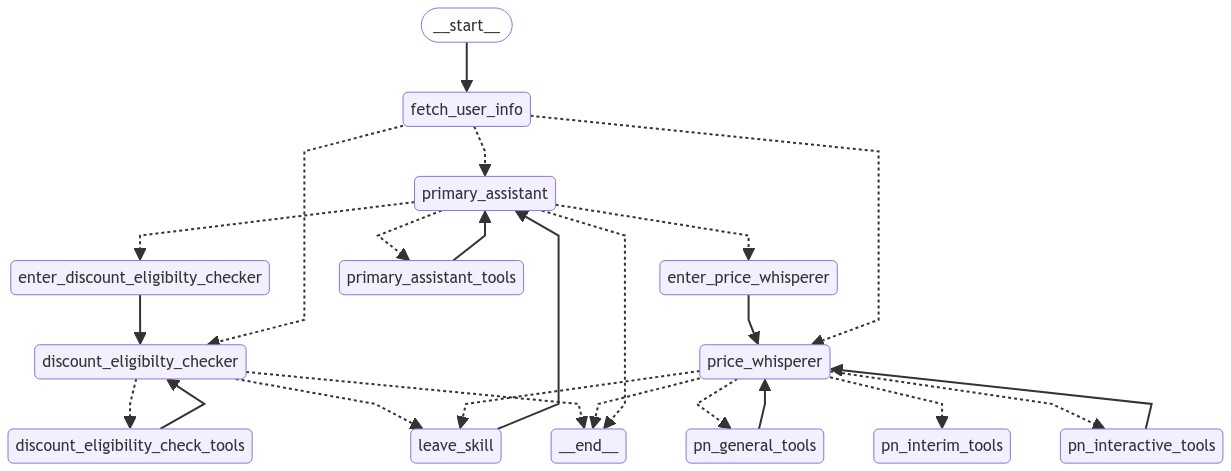

In [103]:
from IPython.display import Image, display

try:
    display(Image(price_whisperer_bot_graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [104]:
tutorial_questions = [
    # "What is the discount on the saucepan?",
    "Hi there, am I eligible for the discount?",
    "What is the discount on the saucepan?",
    "Can I start the price negotiation?"
    "I want to counter offer",
    "My counter offer is 25%",
    "This is too low. My counter offer is 19.55%"
    # "Which products I can have discount on?"
    # "Which products I have bought so far?",
    # "What products are available in the products catelogue?",
    # "List all products from Cuisinart"
    # "What is the discount?",
    # "Are you asking about company policies about the discount?",
    # "What products are there in my shopping cart right now?",
    # "Can I get a discount for all products in my shopping cart?",
]

In [105]:
import shutil
import uuid

# Update with the backup file so we can restart from the original place in each section
# shutil.copy(backup_file, db)
thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        # The customer_id is used in our discount eligibilty check tools to
        # fetch the information of user's purchases, wishlist, items in the cart etc.
        "customer_id": "17",
        # Checkpoints are accessed by thread_id
        "thread_id": thread_id,
    }
}


_printed = set()
# We can reuse the tutorial questions from part 1 to see how it does.
for question in tutorial_questions:
    events = price_whisperer_bot_graph.stream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)
    snapshot = price_whisperer_bot_graph.get_state(config)
    # print(f"snapshot {snapshot}")
    # state_check = State.keys('messages')
    # print(f"tool_messages -> {state_check}")
    print(f"snapshot.next {snapshot.next}")
    while snapshot.next:
        # We have an interrupt! The agent is trying to use a tool, and the user can approve or deny it
        # Note: This code is all outside of your graph. Typically, you would stream the output to a UI.
        # Then, you would have the frontend trigger a new run via an API call when the user has provided input.
        user_input = input(
            "Do you approve of the above actions? Type 'y' to continue;"
            " otherwise, explain your requested changed.\n\n"
        )
        if user_input.strip() == "y":
            # Just continue
            result = price_whisperer_bot_graph.invoke(
                None,
                config,
            )
        else:
            # Satisfy the tool invocation by
            # providing instructions on the requested changes / change of mind
            result = price_whisperer_bot_graph.invoke(
                {
                    "messages": [
                        ToolMessage(
                            tool_call_id=event["messages"][-1].tool_calls[0]["id"],
                            content=f"API call denied by user. Reasoning: '{user_input}'. Continue assisting, accounting for the user's input.",
                        )
                    ]
                },
                config,
            )
        snapshot = price_whisperer_bot_graph.get_state(config)

================================ Human Message =================================

Hi there, am I eligible for the discount?
================================== Ai Message ==================================

Hello! I can help you with that. I'll check your eligibility for discounts right away. Please hold on for a moment. 

Initiating the discount eligibility check now.
Tool Calls:
  ToDiscountEligibiltyCheckAssistant (call_0rUnAPPWwGI5R38NZdyZV3ti)
 Call ID: call_0rUnAPPWwGI5R38NZdyZV3ti
  Args:
    information: Checking discount eligibility for Customer One.
Currently in:  discount_eligibilty_checker
================================= Tool Message =================================

The assistant is now the Discount Eligibility Checking Assistant. Reflect on the above conversation between the host assistant and the user. The user's intent is unsatisfied. Use the provided tools to assist the user. Remember, you are Discount Eligibility Checking Assistant, and the eligibity check, negotiat

In [72]:
state = {'messages': 
            [{'content': 'My counter offer is 25%', 
              'type': 'human'}]}

In [74]:
last_message = state['messages'][-1]
print(last_message)

{'content': 'My counter offer is 25%', 'type': 'human'}


In [76]:
last_message['type']

'human'